In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from IPython.display import display

In [ ]:
# Magic command must be outside the class to avoid Colab errors
%matplotlib inline

In [ ]:
class HousePriceRegression:
    """
    Machine Learning Pipeline for Linear Regression Analysis (House Price Prediction).
    Handles preprocessing, model training, evaluation, and actual vs. predicted visualization.
    """

    def __init__(self, filepath: str):
        # UI/UX configuration for plots
        sns.set_theme(style="whitegrid")
        self.primary_color = "#8e44ad" # Elegant purple

        self.model = LinearRegression()

        # Standard column names for the Boston Housing dataset
        self.columns = [
            'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
            'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'Price'
        ]

        # Load Data (Using sep=r'\s+' because data is space-separated)
        try:
            self.df = pd.read_csv(filepath, sep=r'\s+', header=None, names=self.columns)
            print(f"[OK] Dataset '{filepath}' loaded successfully with {self.df.shape[0]} rows.")
        except FileNotFoundError:
            print(f"[Error] File '{filepath}' not found. Please upload it to Colab.")
            self.df = None

    def prepare_data(self):
        """Prepares features (X) and target (y), and splits the data into train and test sets."""
        if self.df is None: return

        print("\n" + "="*30)
        print("=== PHASE 1: DATA PREPROCESSING ===")
        print("="*30)

        # Features (X) are all columns except 'Price'
        self.X = self.df.drop(columns=['Price'])
        # Target (y) is the 'Price' column
        self.y = self.df['Price']

        # Split Data: 80% Train, 20% Test
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42
        )
        print(f"[*] Training Data: {self.X_train.shape[0]} rows")
        print(f"[*] Testing Data: {self.X_test.shape[0]} rows")
        print("[V] Data successfully split and ready for training.")

    def train_and_evaluate(self):
        """Trains the Linear Regression model and calculates evaluation metrics."""
        if self.df is None: return

        print("\n" + "="*35)
        print("=== PHASE 2: MODEL TRAINING & EVALUATION ===")
        print("="*35)

        # Train the model
        self.model.fit(self.X_train, self.y_train)

        # Predict prices on the test data
        self.y_pred = self.model.predict(self.X_test)

        # Calculate Evaluation Metrics
        r2 = r2_score(self.y_test, self.y_pred)
        rmse = np.sqrt(mean_squared_error(self.y_test, self.y_pred))
        mae = mean_absolute_error(self.y_test, self.y_pred)

        print(f"[*] R-Squared (R2) : {r2:.4f} (Model explains {r2*100:.2f}% of price variance)")
        print(f"[*] RMSE           : {rmse:.4f} (Root Mean Squared Error)")
        print(f"[*] MAE            : {mae:.4f} (Mean Absolute Error)")

        # Display top 5 most influential features
        coefficients = pd.DataFrame({
            'Feature': self.X.columns,
            'Coefficient': self.model.coef_
        }).sort_values(by='Coefficient', ascending=False)

        print("\n[*] Top 5 Most Influential Features (Positive Impact):")
        display(coefficients.head())

    def plot_actual_vs_predicted(self):
        """Visualizes the comparison between Actual Prices and Predicted Prices."""
        if self.df is None: return

        print("\n" + "="*35)
        print("=== PHASE 3: PREDICTION VISUALIZATION ===")
        print("="*35)

        plt.figure(figsize=(10, 6))

        # Scatter plot of actual vs predicted
        sns.scatterplot(x=self.y_test, y=self.y_pred, color=self.primary_color, alpha=0.7, s=80)

        # Ideal diagonal line (Perfect prediction line)
        min_val = min(self.y_test.min(), self.y_pred.min())
        max_val = max(self.y_test.max(), self.y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

        plt.title('Actual vs Predicted House Prices', fontsize=14, fontweight='bold')
        plt.xlabel('Actual Price ($1000s)', fontsize=12)
        plt.ylabel('Predicted Price ($1000s)', fontsize=12)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [ ]:
# Initialize and execute regression pipeline
regression_pipeline = HousePriceRegression('4) house Prediction Data Set.csv')

[OK] Dataset '4) house Prediction Data Set.csv' loaded successfully with 506 rows.


In [ ]:
regression_pipeline.prepare_data()


=== PHASE 1: DATA PREPROCESSING ===
[*] Training Data: 404 rows
[*] Testing Data: 102 rows
[V] Data successfully split and ready for training.


In [ ]:
regression_pipeline.train_and_evaluate()


=== PHASE 2: MODEL TRAINING & EVALUATION ===
[*] R-Squared (R2) : 0.6688 (Model explains 66.88% of price variance)
[*] RMSE           : 4.9286 (Root Mean Squared Error)
[*] MAE            : 3.1891 (Mean Absolute Error)

[*] Top 5 Most Influential Features (Positive Impact):


,Feature,Coefficient
5,RM,4.438835
3,CHAS,2.784438
8,RAD,0.262430
2,INDUS,0.040381
1,ZN,0.030110



=== PHASE 3: PREDICTION VISUALIZATION ===


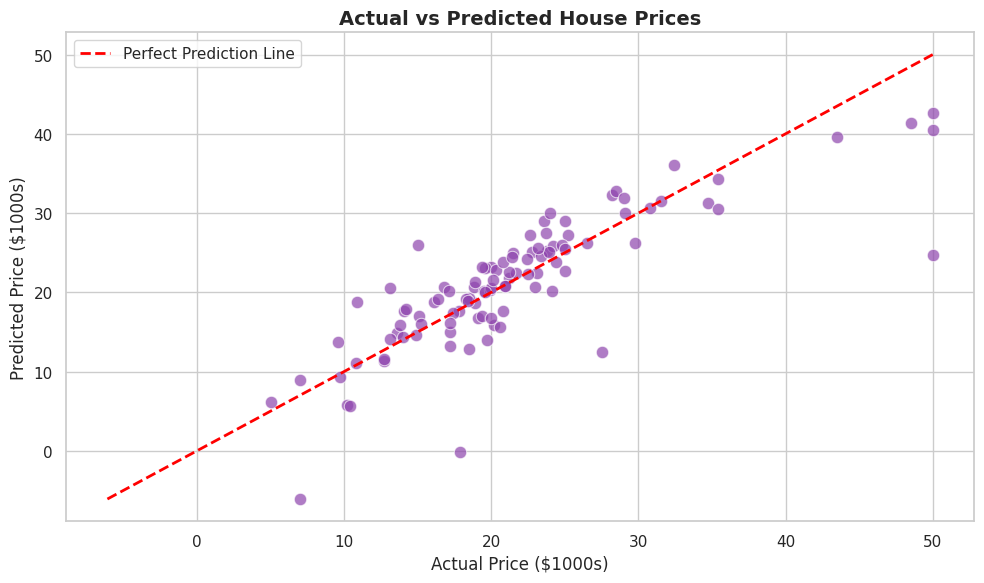

In [ ]:
regression_pipeline.plot_actual_vs_predicted()